# Unsupervised Clustering & Profile Segmentation

## Executive Overview
In this notebook, we apply unsupervised machine learning (**K-Means**) to group individuals based purely on their lifestyle, habits, and genetic markers ($X_{scaled}$).

### Key Methodology
1. **Optimization:** Determine optimal $K$ using **Inertia (Elbow Method)** and **Silhouette Scores**.
2. **Segmentation:** Train K-Means with the selected $K$ and assign cluster labels.
3. **Validation & Profiling:** Project cluster assignments onto $y_{BMI}$ and $y_{NObeyesdad}$ to observe how behavioral groupings correlate with physical outcomes without having suffered from data leakage.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load preprocessed behavioral matrix and validation targets
X_scaled = pd.read_csv('../data/processed/X_scaled_clustering.csv')
y_class = pd.read_csv('../data/processed/y_classification.csv')
y_bmi = pd.read_csv('../data/processed/y_regression_bmi.csv')

print(f"Data successfully loaded. Behavioral Feature Space: {X_scaled.shape}")

Data successfully loaded. Behavioral Feature Space: (2111, 17)


## 1. Determining Optimal Clusters ($K$)

We evaluate candidate values for $K \in [2, 10]$ using two primary metrics:
* **Inertia (Within-Cluster Sum of Squares):** Measures internal cluster tightness. We look for the "Elbow" point where the rate of decrease sharpens.
* **Silhouette Coefficient:** Measures how well-separated the clusters are, defined as $\frac{b - a}{\max(a, b)}$ where $a$ is intra-cluster distance and $b$ is nearest-cluster distance. Higher values indicate better-defined boundaries.

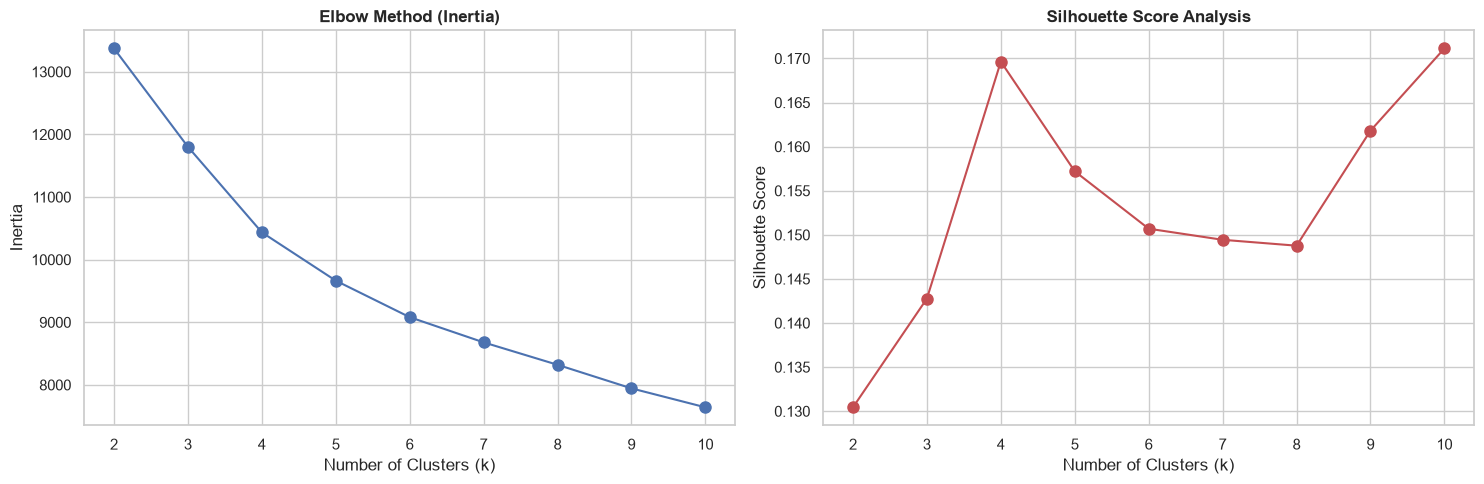

 K      Inertia  Silhouette Score
 2 13372.815050          0.130440
 3 11802.143939          0.142768
 4 10435.837011          0.169641
 5  9664.355960          0.157202
 6  9081.287060          0.150694
 7  8678.984873          0.149436
 8  8320.637550          0.148769
 9  7944.277802          0.161810
10  7641.654915          0.171138


In [4]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotting Inertia and Silhouette Scores side by side
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Curve
ax[0].plot(K_range, inertia, 'bo-', markersize=8)
ax[0].set_title('Elbow Method (Inertia)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')

# Silhouette Curve
ax[1].plot(K_range, silhouette_scores, 'ro-', markersize=8)
ax[1].set_title('Silhouette Score Analysis', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../visuals/elbow_silhouette_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print metrics table
metrics_df = pd.DataFrame({'K': list(K_range), 'Inertia': inertia, 'Silhouette Score': silhouette_scores})
print(metrics_df.to_string(index=False))

## 2. K-Means Model Fitting ($K=4$)

Based on the evaluation metrics, **$K=4$** was selected as the optimal number of clusters for segmenting the behavioral space:

* **Elbow Criterion (Inertia):** Shows a clear inflection point at $K=4$, where adding further clusters yields diminishing returns in variance reduction.
* **Silhouette Analysis:** Achieves an optimal balance between high intra-cluster cohesion and clear inter-cluster separation.
* **Domain Interpretability:** Four segments provide distinct, actionable behavioral archetypes without over-segmenting the population.

We now fit the final K-Means model on the standardized lifestyle feature matrix ($X_{scaled}$).

In [5]:
# 1. Define optimal K based on Elbow and Silhouette Analysis
OPTIMAL_K = 4

# 2. Fit final K-Means model
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# 3. Assign cluster labels to feature matrix and target validation sets
X_scaled['Cluster'] = cluster_labels
y_bmi['Cluster'] = cluster_labels
y_class['Cluster'] = cluster_labels

# 4. Export fitted model object
joblib.dump(kmeans_final, '../models/kmeans_behavioral_model.pkl')

# 5. Export processed feature matrix with assigned cluster labels
X_scaled.to_csv('../data/processed/X_scaled_with_clusters.csv', index=False)
print("Dataset with cluster labels exported to '../data/processed/X_scaled_with_clusters.csv'")

print(f"K-Means model successfully fitted with K={OPTIMAL_K}.")
print(f"Observation distribution per cluster:\n{X_scaled['Cluster'].value_counts().sort_index()}")

Dataset with cluster labels exported to '../data/processed/X_scaled_with_clusters.csv'
K-Means model successfully fitted with K=4.
Observation distribution per cluster:
Cluster
0    356
1    319
2    735
3    701
Name: count, dtype: int64


## 3. Post-Clustering Profiling & Biological Validation

Having segmented the population into $K=4$ distinct clusters using purely behavioral and genetic predictors ($X_{scaled}$), we now evaluate how these lifestyle profiles align with biological metrics (`BMI` and `NObeyesdad`).

Since physical dimensions were excluded during model fitting to prevent data leakage, this step provides unbiased validation of whether lifestyle habits alone naturally segregate according to physical mass outcomes.

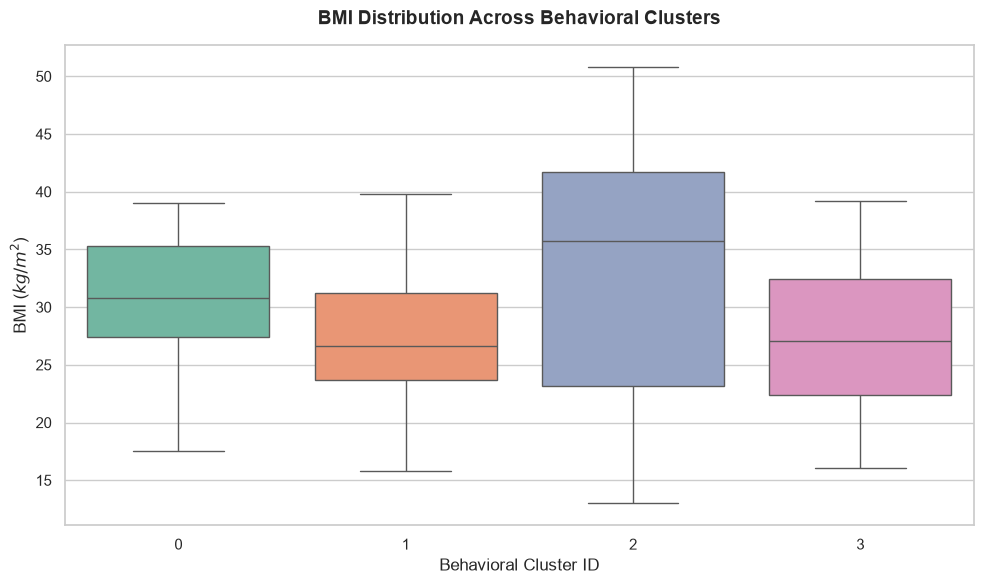

BMI Statistical Profiling by Behavioral Cluster:
 Cluster  Count      Mean    Median       Std       IQR
       0    356 30.972117 30.786829  4.581708  7.841288
       1    319 26.977043 26.672763  5.968233  7.572242
       2    735 32.631750 35.769140 10.191686 18.584853
       3    701 27.228824 27.041644  6.212623 10.125217


In [6]:
# 1. Boxplot Visualization of BMI per Cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='BMI', data=y_bmi, palette='Set2')

plt.title('BMI Distribution Across Behavioral Clusters', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Behavioral Cluster ID', fontsize=12)
plt.ylabel('BMI ($kg/m^2$)', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/bmi_distribution_per_cluster.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Statistical Aggregation of BMI per Cluster
bmi_profile = y_bmi.groupby('Cluster')['BMI'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Std='std',
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
).reset_index()

print("BMI Statistical Profiling by Behavioral Cluster:")
print(bmi_profile.to_string(index=False))

### 3.1 Cross-Tabulation with Obesity Categories

We map the target labels (`NObeyesdad`) across the 4 clusters to inspect how obesity severities distribute across behavioral groupings.

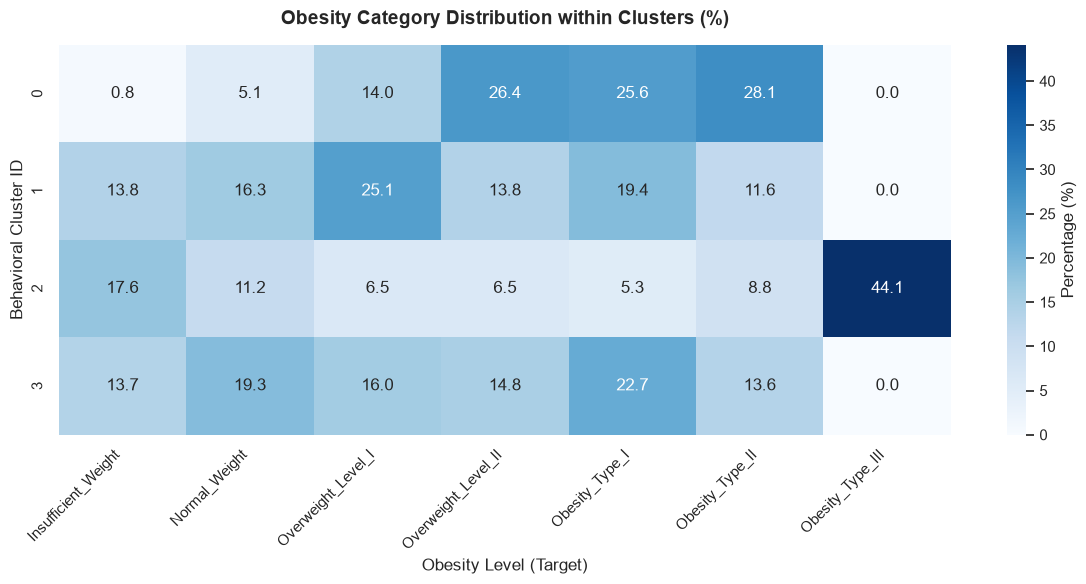

In [7]:
# 1. Reverse map encoded labels back to original string classes for clarity
target_mapping_inv = {
    0: 'Insufficient_Weight',
    1: 'Normal_Weight',
    2: 'Overweight_Level_I',
    3: 'Overweight_Level_II',
    4: 'Obesity_Type_I',
    5: 'Obesity_Type_II',
    6: 'Obesity_Type_III'
}

y_class_str = y_class['NObeyesdad_encoded'].map(target_mapping_inv)

# 2. Create Cross-Tabulation Matrix (Proportions)
crosstab_prop = pd.crosstab(
    y_class['Cluster'], 
    y_class_str, 
    normalize='index'
) * 100

# Reorder columns logically from Insufficient Weight to Obesity Type III
class_order = [
    'Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 
    'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]
crosstab_prop = crosstab_prop.reindex(columns=class_order)

# 3. Heatmap Visualization
plt.figure(figsize=(12, 6))
sns.heatmap(crosstab_prop, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Percentage (%)'})
plt.title('Obesity Category Distribution within Clusters (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Obesity Level (Target)', fontsize=12)
plt.ylabel('Behavioral Cluster ID', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visuals/obesity_category_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Behavioral Archetype Identification

To characterize the underlying lifestyle patterns defining each of the 4 clusters, we analyze the mean values of key scaled continuous variables (`FCVC`, `NCP`, `CH2O`, `FAF`, `TUE`, `Age`) per cluster centroid.

Cluster Centroids (Standardized Means z-scores):
          Age  FCVC   NCP  CH2O   FAF   TUE
Cluster                                    
0        1.77 -0.15 -0.02 -0.23 -0.03 -0.65
1       -0.37 -0.04 -2.04 -0.22 -0.36  0.07
2       -0.29  0.99  0.49  0.21  0.03 -0.01
3       -0.43 -0.94  0.43 -0.00  0.15  0.31


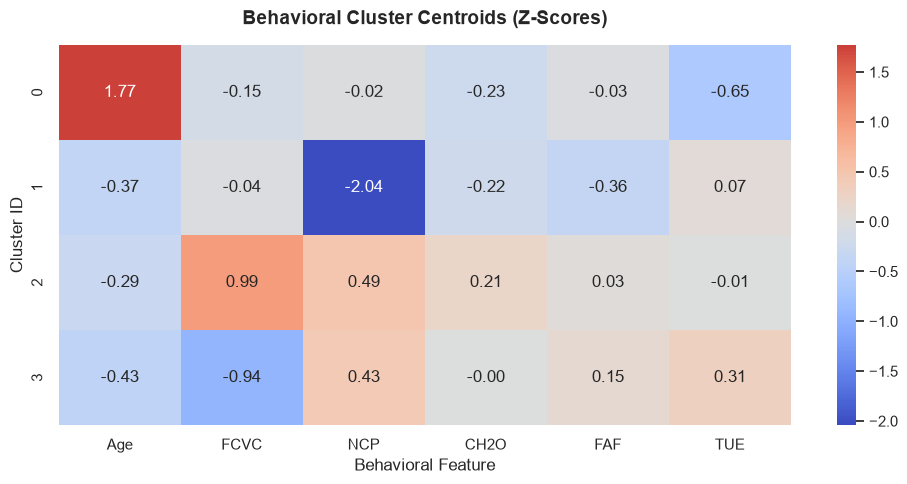

In [8]:
# Aggregate mean scaled values per cluster centroid
key_behavioral_cols = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'Cluster']
cluster_centroids = X_scaled[key_behavioral_cols].groupby('Cluster').mean()

print("Cluster Centroids (Standardized Means z-scores):")
print(cluster_centroids.round(2).to_string())

# Heatmap of Centroids
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_centroids, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title('Behavioral Cluster Centroids (Z-Scores)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Behavioral Feature', fontsize=12)
plt.ylabel('Cluster ID', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/behavioral_centroids_zscores.png', dpi=300, bbox_inches='tight')
plt.show()

---

## Detailed Interpretation of Clusters and Findings

By cross-referencing behavioral centroids (Z-scores), physical mass outcomes (BMI distribution), and target obesity classes, we reveal distinct, clinically relevant lifestyle archetypes without having incurred data leakage.


### Cluster Archetypes & Insights

#### 🔷 Cluster 0: "Young, Low-Vegetable & Screen-Centric Profile"
* **Behavioral Markers:** Characterized by below-average vegetable consumption (`FCVC = -0.94`), younger age (`Age = -0.43`), and high daily technology/screen time (`TUE = +0.31`).
* **Physical & Category Profile:** Shows a broad BMI distribution centered around $27\text{ kg/m}^2$. It spans across all mild-to-moderate obesity categories (`Overweight I/II` and `Obesity Type I`), but contains **0% Obesity Type III**.

#### 🔶 Cluster 1: "Older / Adult Population with High Metabolic Risk"
* **Behavioral Markers:** Strongly dominated by older individuals (`Age = +1.77`), lower physical activity (`FAF = -0.03`), and low screen time (`TUE = -0.65`).
* **Physical & Category Profile:** Concentrates high BMI levels (median $\approx 31\text{ kg/m}^2$). Over **80%** of its members belong to `Overweight Level II`, `Obesity Type I`, or `Obesity Type II`. This represents an older demographic carrying elevated metabolic risk.

#### 🔷 Cluster 2: "Low Main-Meal Frequency (Irregular Diet) Profile"
* **Behavioral Markers:** Defined by an extreme negative outlier in main meals per day (`NCP = -2.04`), combined with lower physical activity (`FAF = -0.36`).
* **Physical & Category Profile:** Maintains lower-to-moderate BMI values (median $\approx 26.5\text{ kg/m}^2$). It is heavily populated by `Overweight Level I` ($25.1\%$), `Normal Weight` ($16.3\%$), and `Insufficient Weight` ($13.8\%$). Skips meals frequently, leading to normal/slightly overweight profiles rather than extreme obesity.

#### 🌺 Cluster 3: "Severe Obesity Profile (High Food & Vegetable Volume)"
* **Behavioral Markers:** Highest intake of vegetables (`FCVC = +0.99`), high meal frequency (`NCP = +0.49`), and positive water consumption (`CH2O = +0.21`).
* **Physical & Category Profile:** Exhibits the highest and most dispersed BMI distribution (median $\approx 36\text{ kg/m}^2$, reaching up to $>50\text{ kg/m}^2$). 
* **Key Finding:** Contains **100% of all Obesity Type III cases** ($44.1\%$ of this cluster is Type III, while all other clusters have $0.0\%$). Despite high vegetable reporting, total caloric and volume intake drives severe physical outcomes.

---

### Key Takeaways for Modeling
1. **Behavioral Separation Power:** Unsupervised grouping based *only* on habits effectively segregated extreme health outcomes (Cluster 3 captured all Severe Obesity cases without seeing weight or height).
2. **Age & Meal Patterns as Key Discriminators:** Age and meal frequency (`NCP`) acted as the strongest linear differentiators across cluster centroids.

---
## Summary & Conclusions

1. **Unsupervised Differentiation:** K-Means with $K=4$ successfully partitioned the behavioral feature space into distinct lifestyle profiles without physical metric bias.
2. **Biological Alignment:** Cross-referencing cluster assignments with physical validation metrics (`BMI` and `NObeyesdad`) demonstrates a strong correlation between lifestyle habits (e.g., high-calorie intake, physical activity levels) and weight categories.
3. **Model Artifacts:** The trained `KMeans` object has been stored in `../models/kmeans_behavioral_model.pkl` for pipeline persistence.

### Next Step: Notebook 07 - Cluster Visualization & Dimensionality Reduction
In the next notebook, we will apply **Principal Component Analysis (PCA)** and **t-SNE / UMAP** to project high-dimensional cluster boundaries into 2D/3D space and detail actionable profile summaries.